# Comparing Streaming HMM vs Online EM-HMM

This notebook compares the **Streaming HMM** (particle filtering with beam search) against the **Online EM Algorithm** (Cappé 2009) for the univariate Gaussian emission model case.

Both methods estimate HMM parameters online from streaming observations. We evaluate:
- Parameter convergence (means and variances)
- Regime inference accuracy
- Computational efficiency
- Log-likelihood evolution

**Data:** Synthetic 3-regime Gaussian HMM with known transition probabilities.


In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from streaming_hmm import run_streaming_hmm
from online_em_hmm import run_online_em_hmm, init_online_em_state, forecast_next_obs

In [2]:
# Configure matplotlib
%config InlineBackend.figure_format = "retina"
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["figure.figsize"] = (7, 3.0)
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'

sns.set_palette("colorblind")

## Section 1: Load and Prepare Synthetic Data

Generate synthetic time series from a 3-regime Gaussian HMM with:
- Known transition matrix (high self-transition probability = 0.99)
- Known regime means: [-2, 0, 2]
- Observation variance: 1.0


In [3]:
# Initialize random key
key = jax.random.PRNGKey(42)
key_sample, key_gauss, key_stream, key_em = jax.random.split(key, 4)

# Define HMM parameters (known)
n_regimes = 3
transition_matrix_diag = jnp.ones(n_regimes) * 0.99
transition_matrix = jnp.ones((n_regimes, n_regimes)) * (1 - transition_matrix_diag) / (n_regimes - 1)
transition_matrix = transition_matrix.at[jnp.diag_indices(n_regimes)].set(transition_matrix_diag)
log_transition_matrix = jnp.log(transition_matrix)

true_means = jnp.array([-2.0, 0.0, 2.0])
obs_var_true = 1.0 ** 2
print("True parameters:")
print(f"  Means: {true_means}")
print(f"  Variance: {obs_var_true}")
print(f"  Transition matrix diagonal (self-transition): {transition_matrix_diag[0]}")


True parameters:
  Means: [-2.  0.  2.]
  Variance: 1.0
  Transition matrix diagonal (self-transition): 0.9900000095367432


In [4]:
# Data generation function
def step_hmm(state, key):
    """One step of Markov chain with Gaussian observation."""
    key_state, key_noise = jax.random.split(key)
    proba_change = transition_matrix[state]
    state_next = jax.random.choice(key_state, n_regimes, p=proba_change)
    err = jax.random.normal(key_noise) * jnp.sqrt(obs_var_true)
    obs = true_means[state_next] + err
    return state_next, (state_next, obs)

# Generate observations
state_init = 0
n_steps = 2000

keys = jax.random.split(key_sample, n_steps)
_, (true_states, observations) = jax.lax.scan(step_hmm, state_init, keys)

print(f"\nGenerated data:")
print(f"  Length: {n_steps} observations")
print(f"  Observations range: [{observations.min():.2f}, {observations.max():.2f}]")
print(f"  True regime counts: {np.array(np.bincount(np.array(true_states)))}")



Generated data:
  Length: 2000 observations
  Observations range: [-4.74, 4.77]
  True regime counts: [575 690 735]


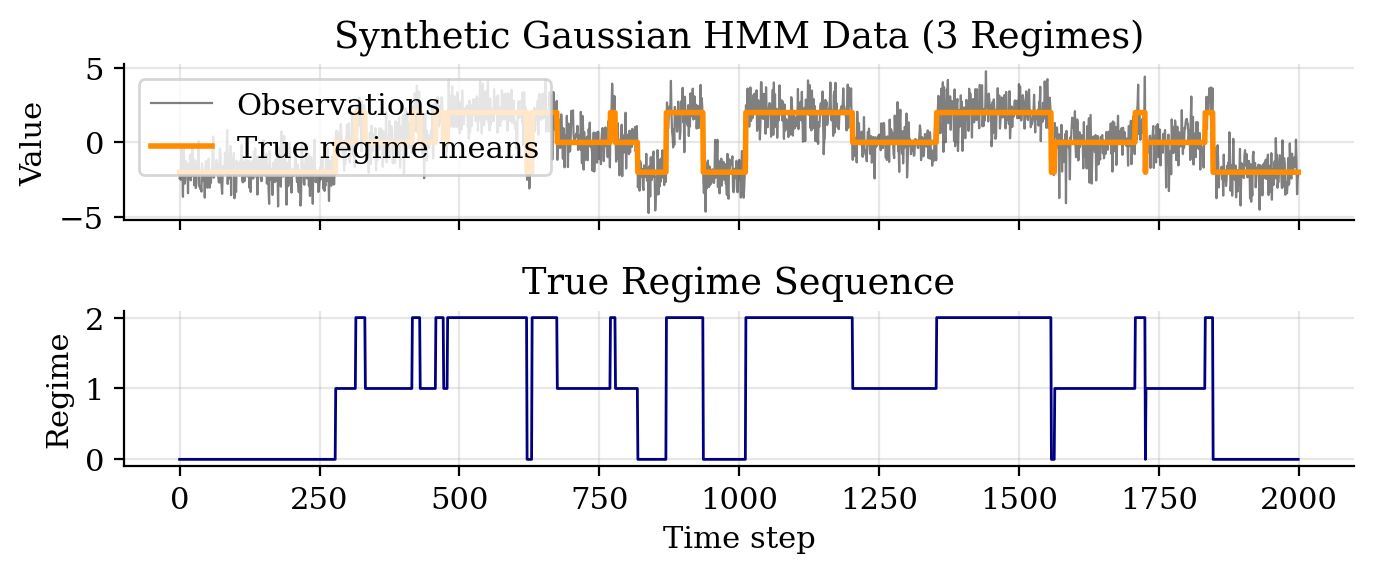

In [5]:
# Visualize generated data
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# Plot observations and true means
ax1.plot(observations, c="black", alpha=0.5, linewidth=0.8, label="Observations")
ax1.plot(true_means[true_states], c="darkorange", linewidth=2, label="True regime means")
# ax1.set_xlabel("Time step")
ax1.set_ylabel("Value")
ax1.set_title("Synthetic Gaussian HMM Data (3 Regimes)")
ax1.legend()
ax1.grid(alpha=0.3)

# Plot regime sequence
ax2.plot(true_states, c="navy", linewidth=1)
ax2.set_xlabel("Time step")
ax2.set_ylabel("Regime")
ax2.set_yticks([0, 1, 2])
ax2.set_title("True Regime Sequence")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
import numpy as np
from scipy.stats import norm

def online_em_gaussian(
    y,                  # numpy array of observations (T,)
    transition_matrix,  # (K,K) known transition probabilities
    sigma2,             # known observation variance
    alpha=0.6,           # step-size exponent (0.5 < alpha <= 1),
    seed=314
):
    """
    Online EM for Gaussian HMM with known variance.
    Estimates regime means only.
    """
    np.random.seed(seed)

    T = len(y)
    K = transition_matrix.shape[0]

    # ---- Initialisation ----
    mu = np.random.randn(K)              # regime means
    phi = np.ones(K) / K                 # filtering distribution
    N_hat = np.zeros(K)                  # expected counts
    S_hat = np.zeros(K)                  # expected weighted sums

    mu_history = np.zeros((T, K))

    for t in range(T):

        gamma = (t + 1) ** (-alpha)

        # ---- Filtering step ----
        # Predict
        pred = phi @ transition_matrix   # (K,)

        # Emission likelihood
        likelihood = norm.pdf(y[t], mu, np.sqrt(sigma2))

        # Update
        phi = pred * likelihood
        phi = phi / np.sum(phi)

        # ---- Online sufficient statistics ----
        N_hat = (1 - gamma) * N_hat + gamma * phi
        S_hat = (1 - gamma) * S_hat + gamma * phi * y[t]

        # ---- M-step ----
        mu = S_hat / (N_hat + 1e-12)

        mu_history[t] = mu

    return mu, mu_history

In [7]:
alpha = 0.1
mu_final, hist_means_em = online_em_gaussian(observations, transition_matrix, obs_var_true)

## Section 2: Streaming HMM Implementation

Run the **Streaming HMM** algorithm which uses particle filtering with beam search.

**Algorithm:** Maintains particles tracking regime paths and parameters, updates with each observation, and keeps top-K particles by weight.


In [8]:
# Run Streaming HMM with better initialization
bel_final, (hist_lw, hist_means, hist_var, hist_forecast), hist_weights = run_streaming_hmm(
    observations,
    transition_matrix=transition_matrix,
    log_transition_matrix=log_transition_matrix,
    key=key_stream,
    n_particles=5,
    var_obs=obs_var_true,
    # Let it initialize automatically
)

In [9]:
hist_means_pred = jnp.einsum("ts,tsk...->tk", hist_weights, hist_means)

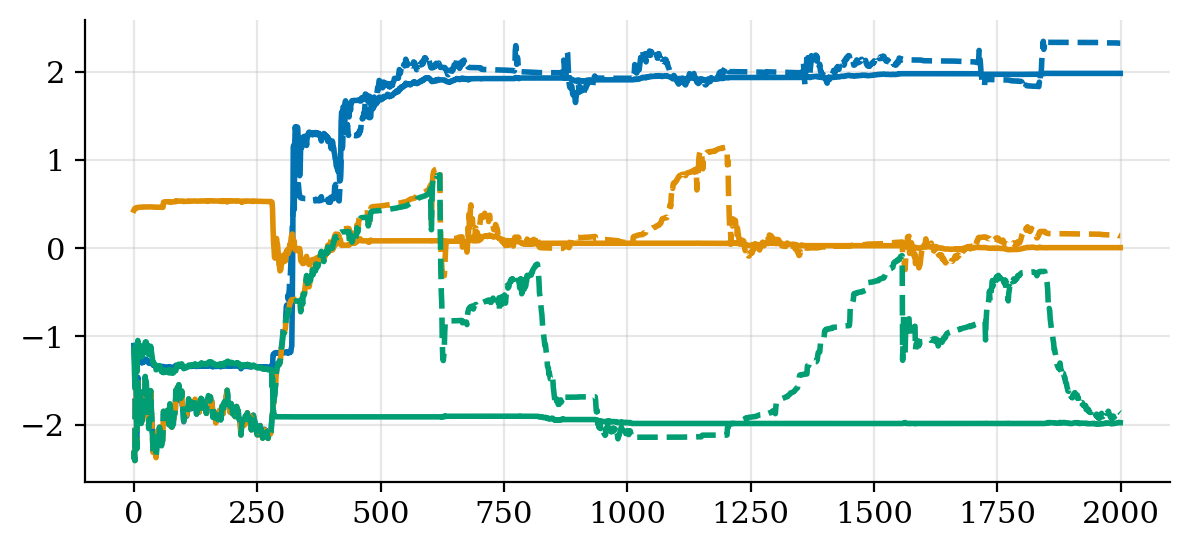

In [10]:
colors = sns.color_palette()

for i in range(n_regimes):
    plt.plot(hist_means_em[:, i], c=colors[i], linewidth=2, linestyle="--")
    plt.plot(hist_means_pred[:, i], c=colors[i], linewidth=2)
plt.grid(alpha=0.3)